In [1]:
!pip install lmfit


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [2]:
import lmfit

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import os
import pathlib
import glob

folder_name = "All_Epithelial"
data = pd.read_csv(f"all_epithelial_cells_distances_and_ordering_8_archetypes/cell_distances.csv",index_col=[0])

for j in range(data.shape[0]):
        # Save the histogram in a specific folder
        new_dir = pathlib.Path(f"{folder_name}/Archetype {j+1}")
        new_dir.mkdir(parents=True, exist_ok=True)
        df= data.iloc[j,:]
        y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
        plt.style.use('seaborn-white')
        plt.xlabel('Distance from Archetype',fontsize=10)
        plt.ylabel('Density',fontsize=10)
        plt.title(f'Distance from Archetype {j+1}',fontsize=14)
        plt.savefig('{}/histogram plot of distance distribution.pdf'.format(new_dir),dpi=300)
        plt.close()

/tmp/ipykernel_273456/939238486.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')
/tmp/ipykernel_273456/939238486.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')
/tmp/ipykernel_273456/939238486.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn AP

In [4]:
data

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X17547,X17548,X17549,X17550,X17551,X17552,X17553,X17554,X17555,X17556
1,12.440681,12.551302,12.677410,12.692389,12.840265,12.891897,12.995540,13.036913,13.071076,13.146744,...,77.448851,77.452259,77.530248,77.582903,77.606401,78.130660,78.512439,79.238205,79.554080,80.033724
2,12.798880,13.731163,13.995552,14.451261,14.632796,14.774040,14.783480,14.946676,15.330478,15.421453,...,79.189941,79.312095,79.398123,79.565796,79.566958,79.863758,80.250268,80.557646,82.023980,82.104152
3,19.166260,21.664425,22.024538,22.752383,22.828097,23.510359,23.834350,23.897825,24.161888,24.204266,...,91.399324,91.959987,92.001109,92.018440,92.100913,92.237854,92.826315,93.177029,93.466721,93.493830
4,11.224418,11.491587,11.559203,11.610412,11.690627,12.074074,12.074604,12.091069,12.113281,12.166452,...,69.112424,69.165065,69.223131,69.456043,69.644181,69.884281,70.075910,70.227657,71.569528,72.267209
5,21.874952,22.800969,22.995660,23.003861,23.161708,23.168120,23.193029,23.329748,23.473899,23.718894,...,88.899831,88.903224,89.303706,89.516397,89.651175,90.176538,90.243201,90.988320,91.304297,91.975793
6,15.275664,16.950370,19.002918,19.251544,19.382042,19.634082,20.499394,20.735001,21.073750,21.128129,...,87.559608,88.086419,88.737424,88.857403,88.969740,89.265030,89.577650,91.586505,92.048292,93.348825
7,12.935878,13.239053,13.312458,13.374482,13.375000,13.448201,13.471503,13.526455,13.593879,13.700493,...,67.301415,67.563817,67.585904,67.621683,67.705742,67.844165,68.009132,68.230157,68.666011,68.818874
8,21.133623,21.877953,22.035907,22.421148,22.457983,22.629867,23.520260,23.924987,24.022502,24.180129,...,95.304838,95.732106,95.884302,95.912581,96.205949,96.292438,96.740765,96.788909,97.332551,97.679836


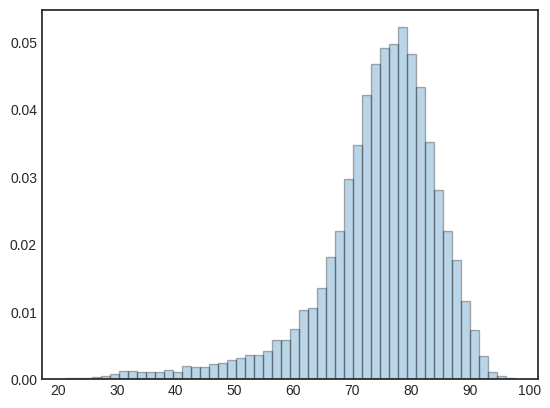

In [5]:
i=8
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [6]:
!pip install rpy2


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.1 -> 24.2
[notice] To update, run: /usr/bin/python3 -m pip install --upgrade pip


In [7]:
%reload_ext rpy2.ipython

In [8]:

%R install.packages('multimode')


* installing *source* package ‘multimode’ ...
** package ‘multimode’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’
using Fortran compiler: ‘GNU Fortran (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’


gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c BinDist2.c -o BinDist2.o
gfortran  -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong  -c  excmasapp.f90 -o excmasapp.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c multimode_init.c -o multimode_init.o
gcc -shared -L/usr/lib/R/lib -Wl,-Bsymbolic-functions -Wl,-z,relro -o multimode.so BinDist2.o excmasapp.o multimode_init.o -lgfortran -lm -lquadmath -L/usr/lib/R/lib -lR


installing to /home/sohom/R/x86_64-pc-linux-gnu-library/4.4/00LOCK-multimode/00new/multimode/libs
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
** building package indices
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (multimode)


Installing package into ‘/home/sohom/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/multimode_1.5.tar.gz'
Content type 'application/x-gzip' length 43077 bytes (42 KB)
downloaded 42 KB


The downloaded source packages are in
	‘/tmp/RtmpCEx8WD/downloaded_packages’
In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


In [9]:
%R install.packages('mixtools')


* installing *source* package ‘mixtools’ ...
** package ‘mixtools’ successfully unpacked and MD5 sums checked
** using staged installation
** libs
using C compiler: ‘gcc (Ubuntu 9.4.0-1ubuntu1~20.04.2) 9.4.0’


gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDEloc2.c -o KDEloc2.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDElocscale.c -o KDElocscale.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDErepeated.c -o KDErepeated.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -g -O2 -fdebug-prefix-map=/build/r-base-ZyAkbF/r-base-4.4.1=. -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2  -c KDErepeatedbw.c -o KDErepeatedbw.o
gcc -I"/usr/share/R/include" -DNDEBUG       -fpic  -

installing to /home/sohom/R/x86_64-pc-linux-gnu-library/4.4/00LOCK-mixtools/00new/mixtools/libs
** R
** data
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** checking absolute paths in shared objects and dynamic libraries
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (mixtools)


Installing package into ‘/home/sohom/R/x86_64-pc-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/mixtools_2.0.0.tar.gz'
Content type 'application/x-gzip' length 706288 bytes (689 KB)
downloaded 689 KB


The downloaded source packages are in
	‘/tmp/RtmpCEx8WD/downloaded_packages’


In [10]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 74.46836   10.29543


/tmp/ipykernel_273456/183709616.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


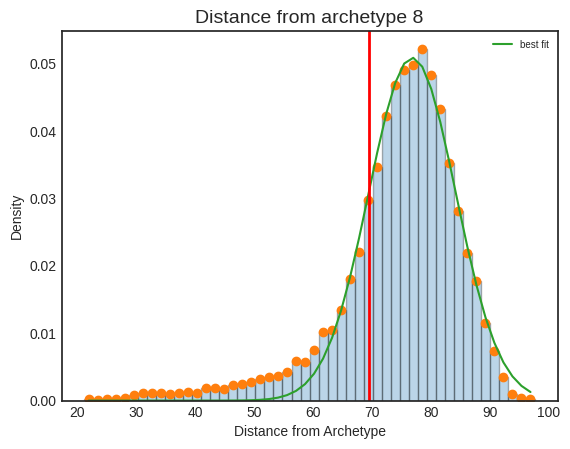

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 8/{folder_name}",  new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

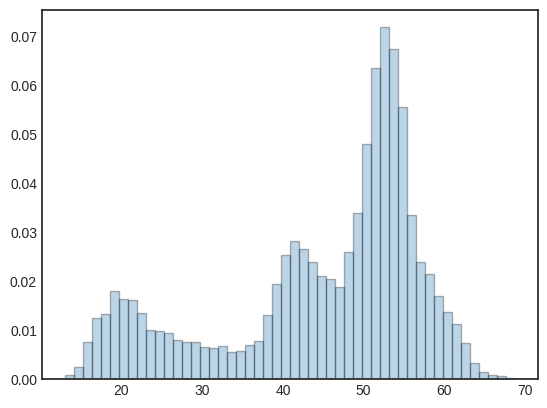

In [23]:
i=7
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.035066, p-value < 2.2e-16
alternative hypothesis: true number of modes is greater than 1

[1] 19.59224 31.86605 32.51069 34.04652 41.42249 46.62896 52.86174
number of iterations= 132 
        mu    sigma    lambda
1 22.87734 5.019082 0.1946493
2 41.13131 3.385840 0.2028857
3 53.18377 4.185863 0.6024649


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


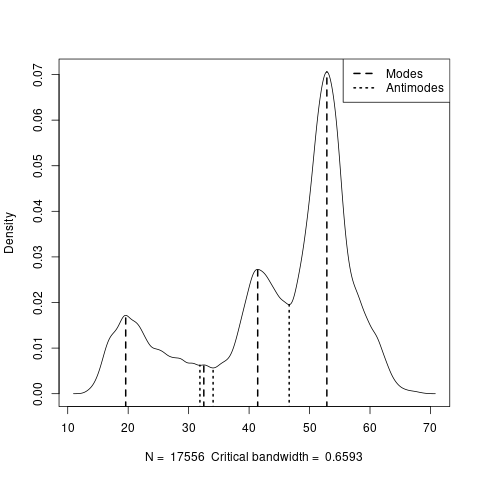

In [24]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=3)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

21.815216874696794
41.785410387458114


/tmp/ipykernel_273456/2859659889.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


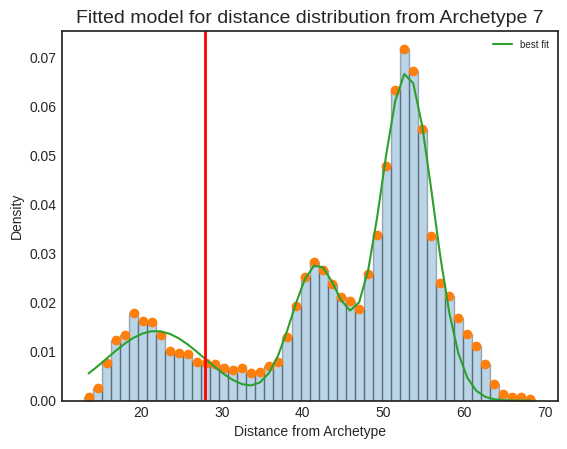

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 7/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

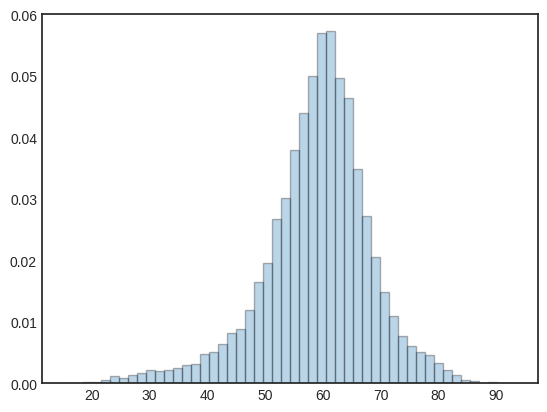

In [20]:
i=6
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [21]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 59.01804   9.275646


/tmp/ipykernel_273456/3252905068.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


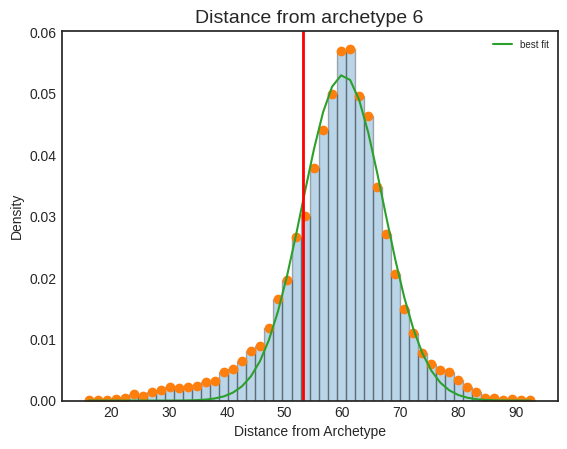

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 6/{folder_name}",  new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

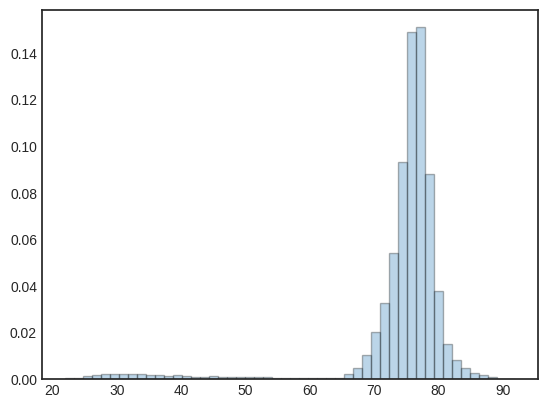

In [134]:
i=5
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")

In [135]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 74.25375   8.981742


/tmp/ipykernel_273456/98435436.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


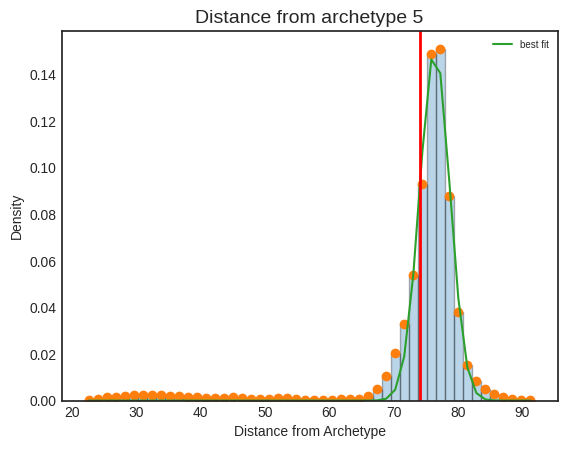

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 5/{folder_name}",  new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

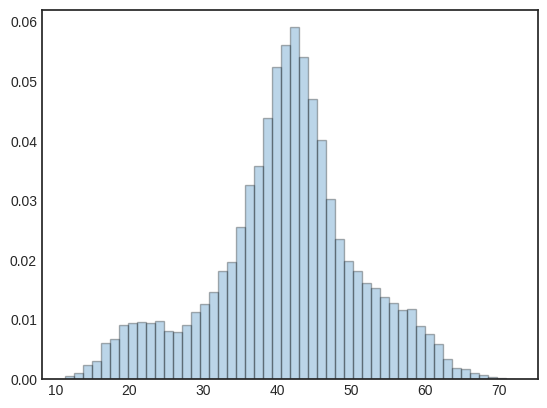

In [132]:
i=4
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.003665, p-value = 0.024
alternative hypothesis: true number of modes is greater than 1

[1] 20.14956 21.17480 23.41725 26.50681 42.60776 71.42520 71.78739
number of iterations= 103 
        mu    sigma   lambda
1 42.06629  3.13436 0.265888
2 40.69456 11.51660 0.734112


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


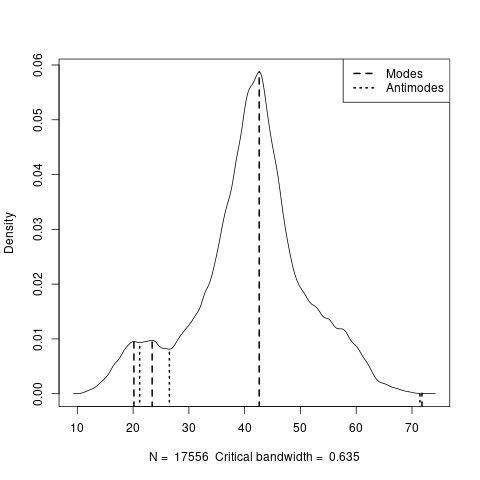

In [133]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=2)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

21.89887791320736
42.06599045731948


/tmp/ipykernel_273456/2124695061.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


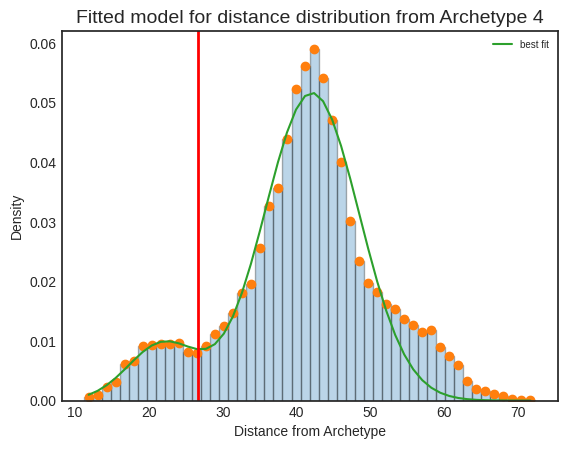

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 4/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

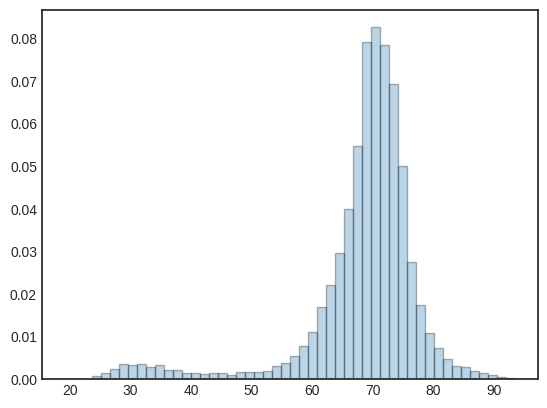

In [120]:
i=3
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.0093535, p-value < 2.2e-16
alternative hypothesis: true number of modes is greater than 1

[1] 19.24782 20.06693 30.60352 42.33838 44.52834 46.54572 70.48456
number of iterations= 280 
        mu    sigma     lambda
1 34.03917 5.812555 0.04816311
2 70.85556 3.417590 0.56793118
3 68.82486 8.126022 0.38390571


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


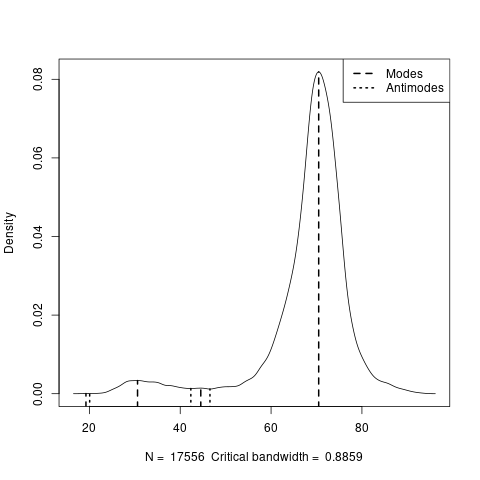

In [121]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=3)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

33.46183307922649
71.07919232035398


/tmp/ipykernel_273456/933355071.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


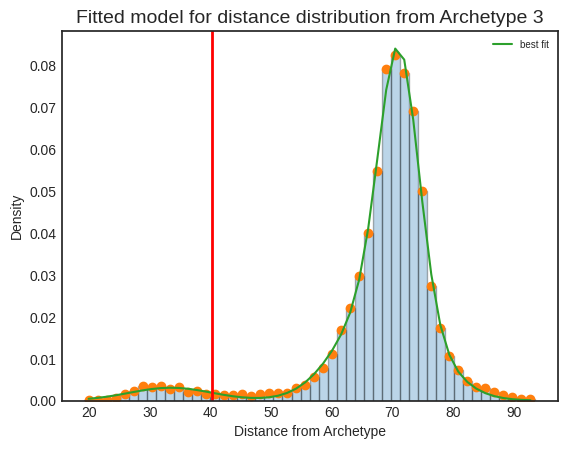

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 3 bi/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

In [41]:
%%R -i df -o fit_result_unimod
library(MASS)
fit <- fitdistr(df, "normal")
para <- fit$estimate
para_mu<-para[1]
para_sigma <- para[2]
fit_result_unimod <- as.data.frame(cbind(para_mu,para_sigma))
fit_result_unimod

      para_mu para_sigma
mean 68.30277    9.69328


/tmp/ipykernel_273456/4212617032.py:29: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


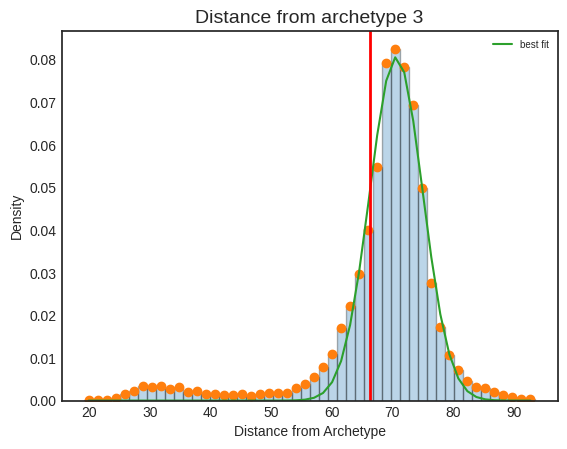

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model

import pathlib
new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 3/{folder_name}",  new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir / f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

gmodel = Model(gauss)
result = gmodel.fit(y, x=x, A=0.8, mu=fit_result_unimod.iloc[0,0], sigma=fit_result_unimod.iloc[0,1])

cut_off_value =result.params['mu'].value - result.params['sigma'].value

result.fit_report()
plt.style.use('seaborn-white')
plt.plot(x, y, 'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Distance from archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

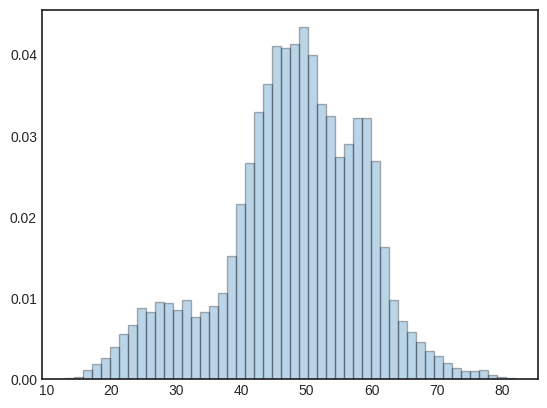

In [82]:
i=2
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.0068346, p-value < 2.2e-16
alternative hypothesis: true number of modes is greater than 1

[1] 28.29323 33.51748 49.00539 55.53975 58.30553 75.65578 75.97695
WARNING! NOT CONVERGENT! 
number of iterations= 1000 
        mu    sigma    lambda
1 27.42193 5.080342 0.1236216
2 45.17176 5.273561 0.3822747
3 55.00005 7.240899 0.4941038


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


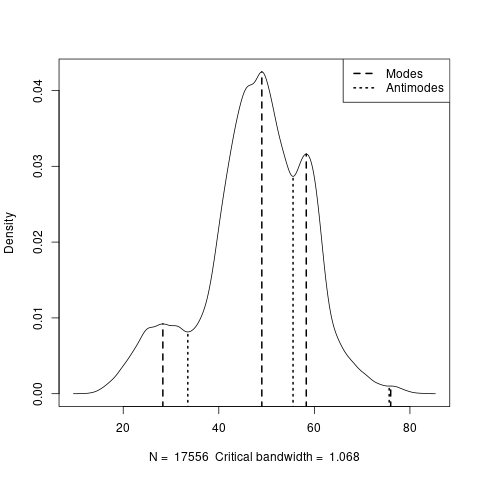

In [83]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=3)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

26.72527310442066
48.02535330582495


/tmp/ipykernel_273456/3747955505.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


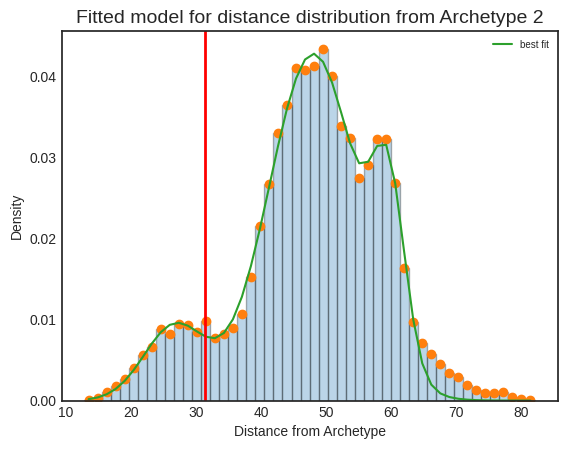

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 2/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   

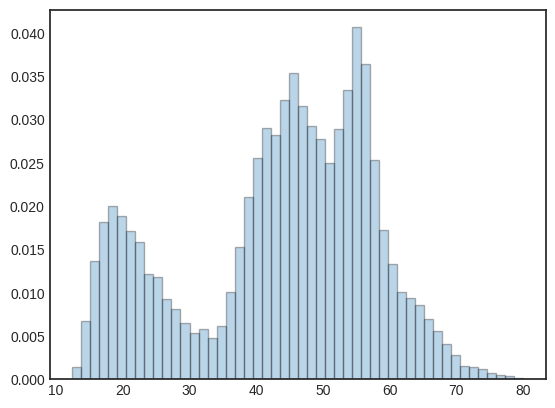

In [94]:
i=1
df= data.iloc[i-1,:]
y= plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")


	Ameijeiras-Alonso et al. (2019) excess mass test

data:  df
Excess mass = 0.049313, p-value < 2.2e-16
alternative hypothesis: true number of modes is greater than 1

[1] 18.87948 33.09536 45.36503 50.81748 55.46249 72.15995 72.86866
number of iterations= 989 
        mu    sigma    lambda
1 21.03375 4.118773 0.2126505
2 45.31992 6.564321 0.5287205
3 55.56316 1.887711 0.1148554
4 60.65840 6.211488 0.1437736


In addition: Warning message:
In locmodes(df, mod0 = 4, display = TRUE, posLegend = "topright") :
  If the density function has an unbounded support, artificial modes may have been created in the tails


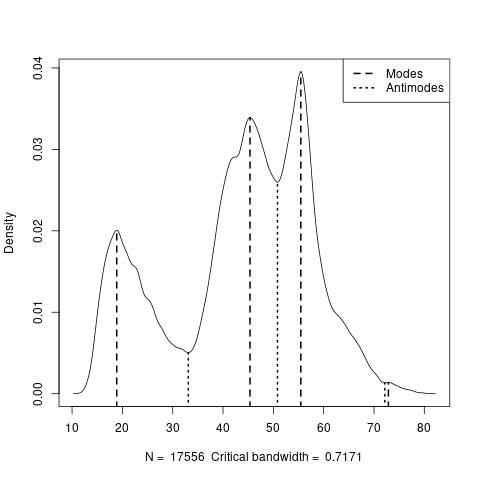

In [95]:
%%R -i df -o fit_result
library(multimode)
library(mixtools)
#path_env <- getwd()
#dir.create(file.path(path_env),recursive = TRUE

# #Testing multimodality (Null hypothesis is - unimodality, alternate hypothesis - multimodality)
print(modetest(df))

# #finding modes (Maximum frequency) and antimodes (least frequent value between two modes)
result <- locmodes(df,mod0=4,display=TRUE,posLegend="topright")
print(result$locations)

## Fitting the data with more than one normal distributions
fit <- normalmixEM(df,k=4)
mu <- fit$mu
sigma <- fit$sigma
lambda <- fit$lambda
fit_result <- as.data.frame(cbind(mu,sigma,lambda))
print(fit_result)

20.409144929695003
44.858121572200574


/tmp/ipykernel_273456/4086855193.py:53: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


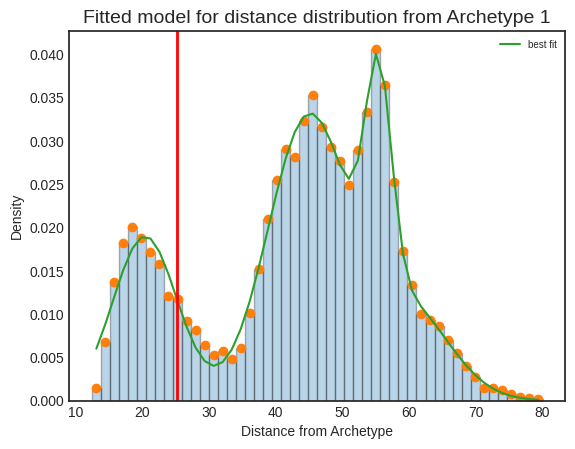

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from lmfit import Model
import pathlib

new_dir_name = f"Archetype {i}"
new_dir = pathlib.Path(f"All_New_Epithelial/Archetype 1/{folder_name}", new_dir_name)
new_dir.mkdir(parents=True, exist_ok=True)
# You have to make a file inside the new directory
new_file = new_dir/f'Archetype {i} fitted distance distribution.txt'

df= data.iloc[i-1,:]
y,x,_ = plt.hist(df,bins=50,histtype="bar",alpha=0.3,density=True,edgecolor="black")
x=(x[1:]+x[:-1])/2

#x, y inputs can be lists or 1D numpy arrays
def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/(2*sigma**2))

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def trimodal(x, mu1, sigma1, A1, mu2, sigma2, A2,mu3,sigma3,A3):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)
    
def tetramodal(x, mu1, sigma1, A1, mu2, sigma2, A2, mu3, sigma3, A3, mu4, sigma4, A4):
     return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)+gauss(x,mu3,sigma3,A3)+gauss(x,mu4,sigma4,A4)

    
if (fit_result.shape[0]==2):
    gmodel = Model(bimodal) 
    #Result for bimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1])  
    
elif (fit_result.shape[0]==3):
    gmodel = Model(trimodal) 
    # Result for trimodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1])
    
else:
    gmodel=Model(tetramodal)
    # Result for tetramodal model
    result = gmodel.fit(y, x=x, A1=fit_result.iloc[0,2], mu1=fit_result.iloc[0,0], sigma1=fit_result.iloc[0,1], A2=fit_result.iloc[1,2], mu2=fit_result.iloc[1,0], sigma2=fit_result.iloc[1,1], A3=fit_result.iloc[2,2], mu3=fit_result.iloc[2,0], sigma3=fit_result.iloc[2,1], A4=fit_result.iloc[3,2], mu4=fit_result.iloc[3,0], sigma4=fit_result.iloc[3,1])

cut_off_value = result.params['mu1'].value + result.params['sigma1'].value
print(result.params['mu1'].value)
print(result.params['mu2'].value)
result.fit_report()

plt.style.use('seaborn-white')
plt.plot(x, y,'o')
plt.xlabel('Distance from Archetype',fontsize=10)
plt.ylabel('Density',fontsize=10)
plt.title(f'Fitted model for distance distribution from Archetype {i}',fontsize=14)
#plt.plot(x, result.init_fit, '--', label='initial fit')
plt.plot(x, result.best_fit, '-', label='best fit')
plt.axvline(x = cut_off_value, color = 'red', linewidth = 2)
plt.legend(prop = { "size": 7}, loc ="upper right")
plt.savefig('{}/fitted model of distance distribution.pdf'.format(new_dir),dpi=300)

#file path
result = result.fit_report()

#File path join to the directory path
with open(new_file, 'w') as f:
    f.write(str(result))   